# Environment Setup

In [ ]:
pip install transformers datasets

In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from transformers import ViTForImageClassification, ViTFeatureExtractor
from torch.optim import AdamW
from torch.nn import CrossEntropyLoss
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import kagglehub

# Download the Kaggle dataset
path = kagglehub.dataset_download("misrakahmed/vegetable-image-dataset")

# Define correct paths for the datasets
train_dir = os.path.join(path, "Vegetable Images", "train")
test_dir = os.path.join(path, "Vegetable Images", "test")
val_dir = os.path.join(path, "Vegetable Images", "validation")

# Define appropriate transformations for ViT
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # ViT espera 3 canais (RGB)
])

# Create datasets
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

# Define number of dataset classes
num_classes = len(train_dataset.classes)

# Load pre-trained ViT model
model = ViTForImageClassification.from_pretrained("google/vit-base-patch16-224", ignore_mismatched_sizes=True)

# Replace the last layer to match the number of dataset classes
model.classifier = torch.nn.Linear(in_features=model.config.hidden_size, out_features=num_classes)

# Move to appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define optimizer and loss function
optimizer = AdamW(model.parameters(), lr=5e-5)
criterion = CrossEntropyLoss()

# Training
epochs = 3
for epoch in range(epochs):
    model.train()
    total_loss = 0
    loop = tqdm(train_loader, desc=f"Treinando Época {epoch+1}/{epochs}")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images).logits  # Remove pixel_values= para evitar erro
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    print(f"Época {epoch+1} - Loss: {total_loss / len(train_loader)}")

# Model evaluation
model.eval()
preds, labels_list = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images).logits  # Remove pixel_values=
        preds.extend(outputs.argmax(dim=1).cpu().numpy())
        labels_list.extend(labels.cpu().numpy())

# Calculate accuracy
acc = accuracy_score(labels_list, preds)
print(f"Acurácia: {acc}")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Treinando Época 1/3: 100%|██████████| 469/469 [10:26<00:00,  1.34s/it, loss=0.00117]


Época 1 - Loss: 0.09350389448070982


Treinando Época 2/3: 100%|██████████| 469/469 [09:26<00:00,  1.21s/it, loss=0.000472]


Época 2 - Loss: 0.0010380540265893337


Treinando Época 3/3: 100%|██████████| 469/469 [09:25<00:00,  1.21s/it, loss=0.000222]


Época 3 - Loss: 0.00036916404779228977
Acurácia: 1.0


In [ ]:
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

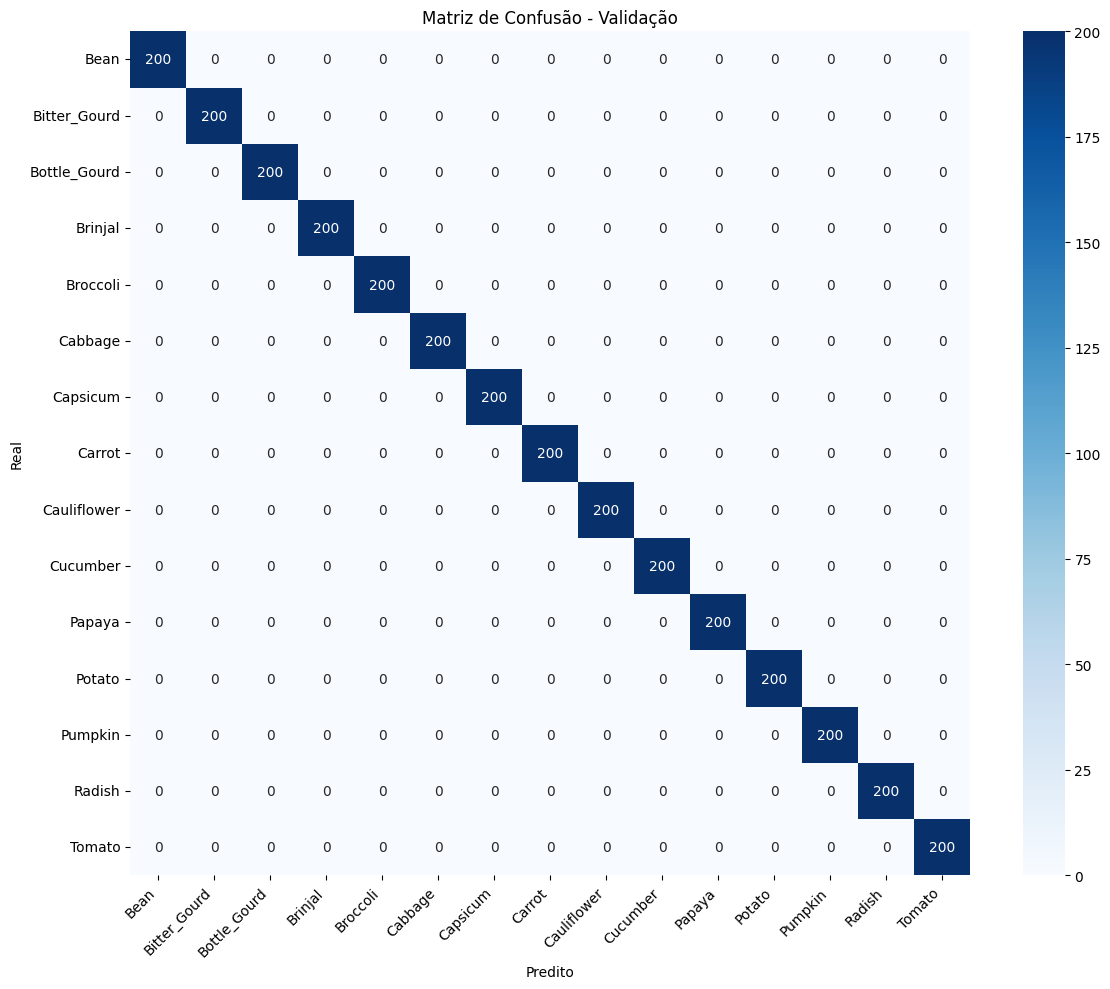

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Generate confusion matrix
cm = confusion_matrix(labels_list, preds)
class_names = train_dataset.classes  # nomes das classes do dataset

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de Confusão - Validação")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()